In [ ]:
import pypsa
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd


import os
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm

In [46]:
TITLE_SIZE = 20

In [47]:
# BAU
sub_folder = '5_8_BAU'
n_cp_reactive = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl0a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc')
n_hr_reactive = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl180a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc')
n_lr_reactive = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl7a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc')
n_lr_proactive = pypsa.Network(f"/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl7a_ch180a_ec_lvopt_3h_E_mapped_TEP.nc")
n_hr_proactive = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_c180a_ec_lvopt_3h_E.nc')

INFO:pypsa.io:Imported network elec_s210_cl0a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc has buses, carriers, generators, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_cl180a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc has buses, carriers, generators, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_cl7a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc has buses, carriers, generators, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_cl7a_ch180a_ec_lvopt_3h_E_mapped_TEP.nc has buses, carriers, generators, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_c180a_ec_lvopt_3h_E.nc has buses, carriers, generators, lines, loads, storage_units


In [48]:
# REM
sub_folder = '5_8_REM'

n_cp_reactive_rem = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl0a_ch180a_ec_lv1.0_REM-3h_E_mapped_TEP.nc')
n_hr_reactive_rem = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl180a_ch180a_ec_lv1.0_REM-3h_E_mapped_TEP.nc')
n_lr_reactive_rem = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl7a_ch180a_ec_lv1.0_REM-3h_E_mapped_TEP.nc')
n_lr_proactive_rem = pypsa.Network(f"/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl7a_ch180a_ec_lvopt_REM-3h_E_mapped_TEP.nc")
n_hr_proactive_rem = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_c180a_ec_lvopt_REM-3h_E.nc')

INFO:pypsa.io:Imported network elec_s210_cl0a_ch180a_ec_lv1.0_REM-3h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_cl180a_ch180a_ec_lv1.0_REM-3h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_cl7a_ch180a_ec_lv1.0_REM-3h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_cl7a_ch180a_ec_lvopt_REM-3h_E_mapped_TEP.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_c180a_ec_lvopt_REM-3h_E.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units


In [49]:
colors = n_hr_reactive.carriers.color

# Extract Statistics

In [50]:
# Extract Line Statistics
# Function to mark lines as interregional or intraregional
def mark_interregional_lines(network):
    network.lines['bus0_zone'] = network.lines['bus0'].map(lambda x: network.buses.loc[x, 'reeds_zone'])
    network.lines['bus1_zone'] = network.lines['bus1'].map(lambda x: network.buses.loc[x, 'reeds_zone'])
    network.lines['interregional'] = network.lines['bus0_zone'] != network.lines['bus1_zone']
    return network
# Mark interregional lines for each network
n_hr_copperplate = mark_interregional_lines(n_cp_reactive)
n_hr_reactive = mark_interregional_lines(n_hr_reactive)
n_lr_reactive = mark_interregional_lines(n_lr_reactive)
n_lr_proactive = mark_interregional_lines(n_lr_proactive)
n_hr_proactive = mark_interregional_lines(n_hr_proactive)


# Calculate the proportion of interregional vs. intraregional transmission capacity
def calculate_transmission_proportions(network):

    # Calculate new capacity for each line (only positive values)
    new_capacity = (network.lines.s_nom_opt - network.lines.s_nom).clip(lower=0)  / 1e3  # Convert to GW
    new_capacity_length = network.lines.length * new_capacity

    # Calculate total new capacity
    total_new_capacity = new_capacity_length.sum()
    
    # Calculate interregional and intraregional capacity
    interregional_capacity = new_capacity_length[network.lines.interregional].sum()
    intraregional_capacity = new_capacity_length[~network.lines.interregional].sum()
    
    # Calculate new transmission CAPEX
    new_expenditure = new_capacity * network.lines.capital_cost * 1e3 / 1e6 # Convert back to MW then div for B$
    interregional_expenditure = new_expenditure[network.lines.interregional].sum()
    intraregional_expenditure = new_expenditure[~network.lines.interregional].sum()

    return {
        'total_capacity': total_new_capacity,
        'interregional_capacity': interregional_capacity,
        'intraregional_capacity': intraregional_capacity,
        'interregional_capacity_prop': interregional_capacity / total_new_capacity * 100,
        'intraregional_capacity_prop': intraregional_capacity / total_new_capacity * 100,
        'interregional_expenditure': interregional_expenditure,
        'intraregional_expenditure': intraregional_expenditure
    }

# Calculate proportions for each network
cp_reactive_data = calculate_transmission_proportions(n_cp_reactive)
lr_reactive_data = calculate_transmission_proportions(n_lr_reactive)
hr_reactive_data = calculate_transmission_proportions(n_hr_reactive)
lr_proactive_data = calculate_transmission_proportions(n_lr_proactive)
hr_proactive_data = calculate_transmission_proportions(n_hr_proactive)


In [51]:
line_statistics_dict = {}
line_statistics_dict['Copperplate Reactive'] = cp_reactive_data
line_statistics_dict['LowRes Reactive'] = lr_reactive_data
line_statistics_dict['HighRes Reactive'] = hr_reactive_data
line_statistics_dict['LowRes Proactive'] = lr_proactive_data
line_statistics_dict['HighRes Proactive'] = hr_proactive_data

line_statistics_dict

{'Copperplate Reactive': {'total_capacity': 21242.29235810565,
  'interregional_capacity': 13680.24114852914,
  'intraregional_capacity': 7562.051209576512,
  'interregional_capacity_prop': 64.40096444350566,
  'intraregional_capacity_prop': 35.59903555649434,
  'interregional_expenditure': 1618.501862808818,
  'intraregional_expenditure': 894.6111204328016},
 'LowRes Reactive': {'total_capacity': 4076.7169845101243,
  'interregional_capacity': 1257.4139890651045,
  'intraregional_capacity': 2819.3029954450203,
  'interregional_capacity_prop': 30.843789103898285,
  'intraregional_capacity_prop': 69.15621089610173,
  'interregional_expenditure': 148.7660190114086,
  'intraregional_expenditure': 333.52032310960135},
 'HighRes Reactive': {'total_capacity': 1539.782867355081,
  'interregional_capacity': 960.3221142934,
  'intraregional_capacity': 579.4607530616811,
  'interregional_capacity_prop': 62.36737235185416,
  'intraregional_capacity_prop': 37.63262764814584,
  'interregional_expen

In [124]:
def extract_statistics(network):
    stats = network.statistics(nice_names=False)

    BESS_stats = stats.loc['StorageUnit'].sum(axis=0)
    idx = pd.MultiIndex.from_tuples([('StorageUnit', 'BESS')])
    bess_df = pd.DataFrame(BESS_stats).T
    bess_df.index = idx

    # Concatenate with original stats dataframe
    stats = pd.concat([stats, bess_df])

    # remove '4hr_battery_storage' from stats
    stats = stats.drop(index=[('StorageUnit', '4hr_battery_storage'), ('StorageUnit', 'battery')])

    return stats

# Create a dictionary to store statistics for each network
statistics_dict = {}

#assign network names to each network
n_cp_reactive.name = 'Copperplate Reactive'
n_lr_reactive.name = 'LowRes Reactive'
n_hr_reactive.name = 'HighRes Reactive'
n_lr_proactive.name = 'LowRes Proactive'
n_hr_proactive.name = 'HighRes Proactive'

# extract stats for REM networks
n_cp_reactive_rem.name = 'Copperplate Reactive REM'
n_lr_reactive_rem.name = 'LowRes Reactive REM'
n_hr_reactive_rem.name = 'HighRes Reactive REM'
n_lr_proactive_rem.name = 'LowRes Proactive REM'
n_hr_proactive_rem.name = 'HighRes Proactive REM'

# Iterate through each network
for network in [
    n_cp_reactive, n_lr_reactive, n_hr_reactive, n_lr_proactive, n_hr_proactive, 
    n_cp_reactive_rem, n_lr_reactive_rem, n_hr_reactive_rem, n_lr_proactive_rem, n_hr_proactive_rem
    ]:
    statistics_dict[network.name] = extract_statistics(network)


# Create the output directory if it doesn't exist
output_dir = "texas_stats"
os.makedirs(output_dir, exist_ok=True)

# Export statistics for each network as a CSV
for name, stats in statistics_dict.items():
    # Replace spaces with underscores and remove special characters for filename
    safe_name = name.replace(" ", "_").replace("/", "_")
    output_path = os.path.join(output_dir, f"{safe_name}_statistics.csv")
    stats.to_csv(output_path)

In [142]:
# Build a DataFrame of optimal capacities for all networks for comparison
# Only include Generators and StorageUnit, drop the first level of the MultiIndex
capacities_list = []
network_names = []
for name, stats in statistics_dict.items():
    cap = stats['Optimal Capacity']
    cap = cap.loc[['Generator', 'StorageUnit']]
    cap = cap.droplevel(0)
    capacities_list.append(cap)
    network_names.append(name)

capacities = pd.concat(capacities_list, axis=1)
capacities.columns = network_names
capacities.mul(1e-3).round(1).to_csv('capacities.csv')


In [144]:
capacities.round(1)

,Copperplate Reactive,LowRes Reactive,HighRes Reactive,LowRes Proactive,HighRes Proactive,Copperplate Reactive REM,LowRes Reactive REM,HighRes Reactive REM,LowRes Proactive REM,HighRes Proactive REM
CCGT,42647.7,44160.4,43907.5,43645.7,43910.9,36253.4,35497.3,34447.5,35429.2,35840.5
CCGT-95CCS,0.0,0.0,0.0,0.0,0.0,16543.9,20002.4,21674.0,19696.0,17331.3
OCGT,12271.1,11482.5,12429.3,11739.7,10822.0,7806.2,7601.0,6658.5,7811.5,7694.3
biomass,125.8,125.8,125.8,125.8,125.8,125.8,125.8,125.8,125.8,125.8
coal,12622.8,12621.8,12192.5,12621.7,14329.7,0.0,0.0,0.0,0.0,0.0
hydro,555.1,555.1,555.1,555.1,555.1,555.1,555.1,555.1,555.1,555.1
hydrogen_ct,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
nuclear,5138.6,5138.6,5138.6,5138.6,5138.6,5138.6,5138.6,5138.6,5138.6,5138.6
offwind,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
oil,707.7,707.7,707.7,707.7,707.7,707.7,707.7,707.7,707.7,707.7


In [54]:
total_costs_dict = {}
for name, stats in statistics_dict.items():
    capex = stats['Capital Expenditure']
    capex = capex.loc[['Generator','Line', 'StorageUnit']]
    #combine 4hr_battery_storage and battery
    capex = capex.droplevel(0)
    capex.rename(index={'AC': 'Transmission'}, inplace=True)

    # do same for opex
    opex = stats['Operational Expenditure']
    opex = opex.loc[['Generator','Line', 'StorageUnit']] 
    opex = opex.droplevel(0)
    opex.rename(index={'AC': 'Transmission'}, inplace=True)

    # sum the values with same index
    total_costs = capex + opex

    # assign to new dictionary
    total_costs_dict[name] = total_costs


total_costs_dict[name]

,2040
CCGT,2.139840e+09
CCGT-95CCS,6.480866e+09
OCGT,1.844082e+08
biomass,7.369984e+07
coal,9.687746e+01
hydro,9.701089e+07
hydrogen_ct,6.166144e+02
nuclear,1.177987e+09
offwind,5.580242e+01
oil,NaN


In [55]:
# Colors
colors = n_hr_reactive.carriers.color
colors['Transmission'] = colors['AC']
colors['BESS'] = colors['battery']
color_map = colors.to_dict()

/var/folders/00/vqry7y9s78q3rvf_m_jmk_bc0000gn/T/ipykernel_3657/2314454798.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



# Total System Cost

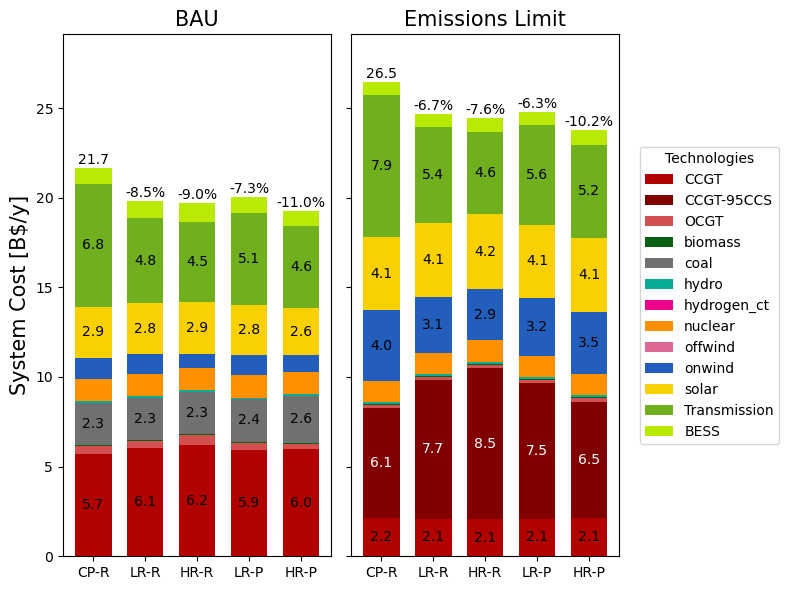

In [56]:
# Create stacked bar plot of total costs
total_costs_dict

LABEL_FONT_SIZE = 10
TITLE_FONT_SIZE = 15

# Extract data for plotting
network_names = list(total_costs_dict.keys())
technologies = list(total_costs_dict[network_names[0]].index)

# define order of networks
network_names = ['Copperplate Reactive', 'LowRes Reactive', 'HighRes Reactive', 'LowRes Proactive', 'HighRes Proactive']
network_names_rem = ['Copperplate Reactive REM', 'LowRes Reactive REM', 'HighRes Reactive REM', 'LowRes Proactive REM', 'HighRes Proactive REM']
# Define alternate names for x-axis labels
network_labels = {
    'Copperplate Reactive': 'CP-R',
    'LowRes Reactive': 'LR-R',
    'HighRes Reactive': 'HR-R', 
    'LowRes Proactive': 'LR-P',
    'HighRes Proactive': 'HR-P'
}

# Add labels to plot
network_rem_labels = {
    'Copperplate Reactive REM': 'CP-R',
    'LowRes Reactive REM': 'LR-R',
    'HighRes Reactive REM': 'HR-R',
    'LowRes Proactive REM': 'LR-P', 
    'HighRes Proactive REM': 'HR-P'
}


# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,6))

# Add titles to subplots
ax1.set_title('BAU', fontsize=TITLE_FONT_SIZE)
ax2.set_title('Emissions Limit', fontsize=TITLE_FONT_SIZE)

# First subplot - original networks
x1 = np.arange(len(network_names))
width = 0.7
bottom1 = np.zeros(len(network_names))

# Second subplot - REM networks  
x2 = np.arange(len(network_names_rem))
bottom2 = np.zeros(len(network_names_rem))

# Create stacked bars for each subplot
for tech in technologies:
    # Values for original networks
    values1 = [total_costs_dict[network].loc[tech][2040] /1e9 for network in network_names]
    if not np.isnan(values1).all():
        ax1.bar(x1, values1, width, bottom=bottom1, label=tech, color=color_map[tech])
        bottom1 += np.nan_to_num(values1)
        
    # Values for REM networks    
    values2 = [total_costs_dict[network].loc[tech][2040] /1e9 for network in network_names_rem]
    if not np.isnan(values2).all():
        ax2.bar(x2, values2, width, bottom=bottom2, label=tech, color=color_map[tech])
        bottom2 += np.nan_to_num(values2)


# Add value labels for first subplot
for i, network in enumerate(network_names):
    bottom = 0
    for tech in technologies:
        value = total_costs_dict[network].loc[tech][2040] / 1e9
        if not np.isnan(value) and abs(value) >= 1.5:
            height = value
            ax1.text(i, bottom + height/2, f'{value:.1f}', 
                    ha='center', va='center',
                    color='black', 
                    fontsize=LABEL_FONT_SIZE)
            bottom += height
        elif not np.isnan(value):
            bottom += value
            
# Add value labels for second subplot            
for i, network in enumerate(network_names_rem):
    bottom = 0
    for tech in technologies:
        value = total_costs_dict[network].loc[tech][2040] / 1e9
        if not np.isnan(value) and abs(value) >= 1.5:
            height = value
            if tech == 'CCGT-95CCS':
                TEXT_COLOR = 'white'
            else:
                TEXT_COLOR = 'black'
            ax2.text(i, bottom + height/2, f'{value:.1f}',
                    ha='center', va='center',
                    color=TEXT_COLOR,
                    fontsize=LABEL_FONT_SIZE)
            bottom += height
        elif not np.isnan(value):
            bottom += value

# Calculate totals for first subplot
total_heights1 = []
for network in network_names:
    total = 0
    for tech in technologies:
        value = total_costs_dict[network].loc[tech][2040] / 1e9
        if not np.isnan(value):
            total += value
    total_heights1.append(total)

# Calculate totals for second subplot    
total_heights2 = []
for network in network_names_rem:
    total = 0
    for tech in technologies:
        value = total_costs_dict[network].loc[tech][2040] / 1e9
        if not np.isnan(value):
            total += value
    total_heights2.append(total)

# Add total and reduction labels for first subplot
ax1.text(0, total_heights1[0] + 0.05, f'{total_heights1[0]:.1f}',
         ha='center', va='bottom',
         color='black',
         fontsize=LABEL_FONT_SIZE)

for i in range(1, len(network_names)):
    pct_reduction = ((total_heights1[0] - total_heights1[i]) / total_heights1[0]) * 100
    ax1.text(i, total_heights1[i] + 0.05, f'-{pct_reduction:.1f}%',
             ha='center', va='bottom', 
             color='black',
             fontsize=LABEL_FONT_SIZE)

# Add total and reduction labels for second subplot             
ax2.text(0, total_heights2[0] + 0.05, f'{total_heights2[0]:.1f}',
         ha='center', va='bottom',
         color='black', 
         fontsize=LABEL_FONT_SIZE)

for i in range(1, len(network_names_rem)):
    pct_reduction = ((total_heights2[0] - total_heights2[i]) / total_heights2[0]) * 100
    ax2.text(i, total_heights2[i] + 0.05, f'-{pct_reduction:.1f}%',
             ha='center', va='bottom',
             color='black',
             fontsize=LABEL_FONT_SIZE)


# Set x-axis labels
ax1.set_xticks(x1)
ax1.set_xticklabels([network_labels[n] for n in network_names])
ax2.set_xticks(x2) 
ax2.set_xticklabels([network_labels[n.replace(' REM','')] for n in network_names_rem])


# Add legend to right of second subplot
ax2.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', title='Technologies')

# Set same y limits for both plots
max_height = max(max(total_heights1), max(total_heights2))
ax1.set_ylim(0, max_height * 1.1)
ax2.set_ylim(0, max_height * 1.1)

# set one y axis label
ax1.set_ylabel('System Cost [B$/y]', fontsize=TITLE_FONT_SIZE)
#remove y axis tick labels for second subplot
ax2.set_yticklabels([])
plt.tight_layout()

## Analyze price divergence in final networks

In [57]:
networks_bau = []
networks_bau.append(n_cp_reactive)
networks_bau.append(n_lr_reactive)
networks_bau.append(n_hr_reactive)
networks_bau.append(n_lr_proactive)
networks_bau.append(n_hr_proactive)



In [74]:
mp = n_hr_reactive.buses_t.marginal_price.loc[2040].T
zone_map = n_hr_reactive.buses.reeds_zone
mp.index = pd.MultiIndex.from_arrays([zone_map.loc[mp.index].values, mp.index], names=['zone', 'bus'])
mp

timestep     2040-01-01 00:00:00  2040-01-01 03:00:00  2040-01-01 06:00:00  \
zone bus                                                                     
p60  p600 0            18.399395             0.020205             0.020205   
p61  p610 0            49.127840            26.778479             2.592983   
     p610 1            10.999831             0.019924             0.020126   
     p610 2            22.552738             5.581444             0.432421   
p62  p620 0            19.510720             1.494126             0.172426   
...                          ...                  ...                  ...   
p67  p670 5            26.452118            26.011216            23.151038   
     p670 6            32.155260            26.645527            23.156336   
     p670 7            31.487565            26.482447            23.104651   
     p670 8            31.253226            26.396554            23.109867   
     p670 9            32.154339            26.710365            23.194612   

timestep     2040-01-01 09:00:00  2040-01-01 12:00:00  2040-01-01 15:00:00  \
zone bus                                                                     
p60  p600 0             0.020216            20.923115            18.193114   
p61  p610 0             0.019761            20.356629            15.030567   
     p610 1             0.020126            20.514136            17.914861   
     p610 2             0.020951            17.366155            14.347000   
p62  p620 0             0.020668            20.869007            17.589824   
...                          ...                  ...                  ...   
p67  p670 5            23.015834            23.279863            21.527921   
     p670 6            23.043372            23.187351            21.463574   
     p670 7            22.968324            23.161051            21.439387   
     p670 8            22.941222            23.127533            21.175967   
     p670 9            23.060809            23.217566            21.581873   

timestep     2040-01-01 18:00:00  2040-01-01 21:00:00  2040-01-02 00:00:00  \
zone bus                                                                     
p60  p600 0             0.755408            20.105555            24.373534   
p61  p610 0             0.863412            17.410125            24.086554   
     p610 1             0.749570            19.980005            24.298598   
     p610 2             0.018731             0.018770            23.838418   
p62  p620 0             0.758045            19.861000            23.795129   
...                          ...                  ...                  ...   
p67  p670 5            18.743000            21.554034            25.546286   
     p670 6            18.219268            21.526847            26.009518   
     p670 7            19.043712            21.479754            25.891439   
     p670 8            16.764389            21.397062            25.750119   
     p670 9            20.427270            21.605391            26.105028   

timestep     2040-01-02 03:00:00  ...  2040-12-30 18:00:00  \
zone bus                          ...                        
p60  p600 0            23.962405  ...             0.021137   
p61  p610 0            23.448642  ...             0.019904   
     p610 1            23.934519  ...             0.020127   
     p610 2            23.434164  ...             0.018733   
p62  p620 0            23.431374  ...             0.021077   
...                          ...  ...                  ...   
p67  p670 5            25.546286  ...            23.158005   
     p670 6            25.826264  ...            23.110823   
     p670 7            25.726315  ...            23.050317   
     p670 8            25.678071  ...            23.003993   
     p670 9            25.904278  ...            23.184592   

timestep     2040-12-30 21:00:00  2040-12-31 00:00:00  2040-12-31 03:00:00  \
zone bus                                                              

In [79]:
lmp_data = {}  
for network in networks_bau:
    mp = network.buses_t.marginal_price.loc[2040].T
    zone_map = network.buses.reeds_zone
    mp.index = pd.MultiIndex.from_arrays([zone_map.loc[mp.index].values, mp.index], names=['zone', 'bus'])
    lmp_data[network.name] = mp
lmp_data['Copperplate Reactive']

timestep     2040-01-01 00:00:00  2040-01-01 03:00:00  2040-01-01 06:00:00  \
zone bus                                                                     
p60  p600 0            21.220092            18.865660            17.315618   
p61  p610 0            22.049721            19.821923            16.688633   
     p610 1            20.351920            17.704627            15.020174   
     p610 2            19.431563            18.889759            13.516155   
p62  p620 0            21.226738            18.710013            17.421097   
...                          ...                  ...                  ...   
p67  p670 5            28.109254            25.547896            23.269251   
     p670 6            28.703488            25.850162            23.158784   
     p670 7            28.622299            25.829826            23.137477   
     p670 8            28.181925            25.569411            23.093467   
     p670 9            28.884034            25.972239            23.205467   

timestep     2040-01-01 09:00:00  2040-01-01 12:00:00  2040-01-01 15:00:00  \
zone bus                                                                     
p60  p600 0            18.020176            22.028381            17.241010   
p61  p610 0            16.751191            19.517241            12.882815   
     p610 1            15.785027            21.891630            17.409864   
     p610 2            13.516158            19.208628             0.021461   
p62  p620 0            17.768936            21.924360            17.225121   
...                          ...                  ...                  ...   
p67  p670 5            23.083345            23.867617            21.556086   
     p670 6            23.099795            23.755137            21.438775   
     p670 7            23.062967            23.734181            21.499264   
     p670 8            23.063988            23.682278            21.298741   
     p670 9            23.162385            23.794417            21.534296   

timestep     2040-01-01 18:00:00  2040-01-01 21:00:00  2040-01-02 00:00:00  \
zone bus                                                                     
p60  p600 0             0.123918            17.274499            24.271188   
p61  p610 0             0.076576            15.241999            24.493486   
     p610 1             0.120571            17.420811            24.301547   
     p610 2             0.018101             0.018101            24.313663   
p62  p620 0             0.111208            15.939654            24.286215   
...                          ...                  ...                  ...   
p67  p670 5             0.502205            21.626534            25.745755   
     p670 6             0.495615            21.501288            26.396773   
     p670 7             0.497866            21.482893            26.329007   
     p670 8             0.489677            21.404394            25.962700   
     p670 9             0.504102            21.586261            26.529005   

timestep     2040-01-02 03:00:00  ...  2040-12-30 18:00:00  \
zone bus                          ...                        
p60  p600 0            24.256778  ...            17.932374   
p61  p610 0            24.474249  ...            15.282455   
     p610 1            24.284249  ...            16.689813   
     p610 2            24.304014  ...             0.021462   
p62  p620 0            24.271189  ...            15.816082   
...                          ...  ...                  ...   
p67  p670 5            25.547896  ...            24.196106   
     p670 6            25.940614  ...            23.975770   
     p670 7            25.870038  ...            24.023662   
     p670 8            25.746120  ...            23.718846   
     p670 9            26.050371  ...            24.023012   

timestep     2040-12-30 21:00:00  2040-12-31 00:00:00  2040-12-31 03:00:00  \
zone bus                                                              

In [122]:
# For each network, compute daily median and daily max(abs) prices for each node (bus)
daily_median_prices = {}
daily_maxabs_prices = {}
zonal_daily_median_prices = {}
zonal_daily_maxabs_prices = {}

# To store the difference DataFrames
bus_vs_zone_median_diff = {}
bus_maxabs_vs_zone_median_diff = {}

for net_name, mp in lmp_data.items():
    # mp: DataFrame with MultiIndex (zone, bus), columns are timestamps
    # Transpose so index is timestamps, columns are (zone, bus)
    mp_T = mp.T
    # Convert index to datetime if not already
    if not pd.api.types.is_datetime64_any_dtype(mp_T.index):
        mp_T.index = pd.to_datetime(mp_T.index)
    # Resample to daily, compute median and max(abs) for each (zone, bus)
    daily_median = mp_T.resample('D').median()
    daily_maxabs = mp_T.abs().resample('D').max()
    # Store with same column MultiIndex
    daily_median_prices[net_name] = daily_median
    daily_maxabs_prices[net_name] = daily_maxabs

    # Also compute zonal daily median and max(abs) by grouping columns by zone (level 0 of MultiIndex)
    # Resulting DataFrames have columns as zones, index as days
    zonal_daily_median = daily_median.groupby(level=0, axis=1).median()
    zonal_daily_maxabs = daily_maxabs.groupby(level=0, axis=1).max()
    zonal_daily_median_prices[net_name] = zonal_daily_median
    zonal_daily_maxabs_prices[net_name] = zonal_daily_maxabs

    # Create a DataFrame comparing daily median of each bus to its zonal daily median
    # For each (zone, bus), subtract the zonal median for that zone and day
    # daily_median: index=days, columns=MultiIndex (zone, bus)
    # zonal_daily_median: index=days, columns=zone
    # We'll align by day and zone
    bus_zones = daily_median.columns.get_level_values(0)
    # For each bus, subtract the corresponding zone's daily median
    bus_vs_zone = daily_median.copy()
    for col in daily_median.columns:
        zone = col[0]
        bus_vs_zone[col] = daily_median[col] - zonal_daily_median[zone]
    bus_vs_zone_median_diff[net_name] = bus_vs_zone

    # Create a DataFrame comparing daily max(abs) of each bus to its zonal daily median
    bus_maxabs_vs_zone = daily_maxabs.copy()
    for col in daily_maxabs.columns:
        zone = col[0]
        bus_maxabs_vs_zone[col] = daily_maxabs[col] - zonal_daily_median[zone]
    bus_maxabs_vs_zone_median_diff[net_name] = bus_maxabs_vs_zone

# Example usage:
# bus_vs_zone_median_diff['Copperplate Reactive'] # DataFrame: daily median price difference (bus - zone median)
# bus_maxabs_vs_zone_median_diff['Copperplate Reactive'] # DataFrame: daily max(abs) price difference (bus - zone median)


/var/folders/00/vqry7y9s78q3rvf_m_jmk_bc0000gn/T/ipykernel_3657/4086619283.py:27: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

/var/folders/00/vqry7y9s78q3rvf_m_jmk_bc0000gn/T/ipykernel_3657/4086619283.py:28: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

/var/folders/00/vqry7y9s78q3rvf_m_jmk_bc0000gn/T/ipykernel_3657/4086619283.py:27: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

/var/folders/00/vqry7y9s78q3rvf_m_jmk_bc0000gn/T/ipykernel_3657/4086619283.py:28: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

/var/folders/00/vqry7y9s78q3rvf_m_jmk_bc0000gn/T/ipykernel_3657/4086619283.py:27: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

/var/folders/00/vqry7y9s78q3rvf_m_jmk_bc

/var/folders/00/vqry7y9s78q3rvf_m_jmk_bc0000gn/T/ipykernel_3657/927108262.py:38: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



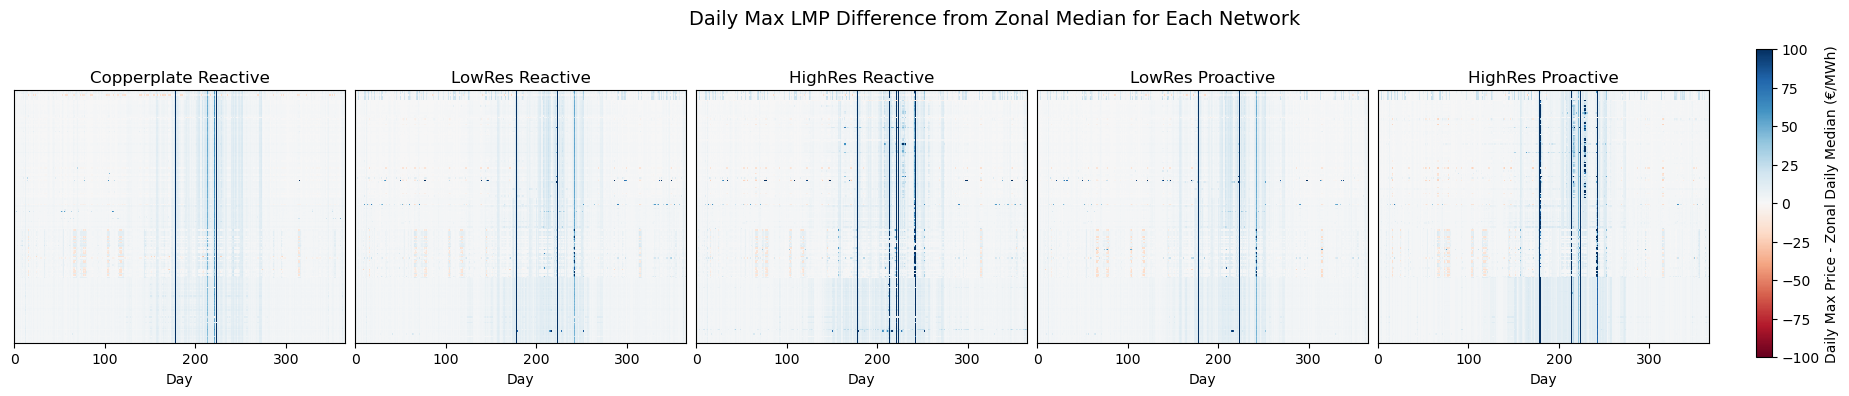

In [123]:
import matplotlib.pyplot as plt

# Prepare for multiple subplots, one per network
networks = list(bus_maxabs_vs_zone_median_diff.keys())
n_nets = len(networks)

# Set up subplots: 1 row, n_nets columns
fig, axes = plt.subplots(1, n_nets, figsize=(4*n_nets, 4), sharex=True, sharey=False)

# If only one network, axes is not a list
if n_nets == 1:
    axes = [axes]

vmax = 100
vmin = -vmax

for i, net_to_plot in enumerate(networks):
    df = bus_maxabs_vs_zone_median_diff[net_to_plot]
    ax = axes[i]
    im = ax.imshow(df.T, aspect='auto', interpolation='none', cmap='RdBu', vmin=vmin, vmax=vmax)
    ax.set_title(net_to_plot, fontsize=12)
    ax.set_xlabel('Day')
    # Remove y-labels for all subplots for compactness
    ax.set_yticks([])
    # Optionally, show y-ticks only for the first subplot
    # if i == 0:
    #     ax.set_ylabel('Bus (zone, bus)')
    #     ax.set_yticks(range(len(df.columns)))
    #     ax.set_yticklabels([f"{z},{b}" for z, b in df.columns], fontsize=6)
    # else:
    #     ax.set_yticks([])

# Add a single colorbar for all subplots
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.025, pad=-0.2)
cbar.set_label('Daily Max Price - Zonal Daily Median (€/MWh)')

plt.suptitle('Daily Max LMP Difference from Zonal Median for Each Network', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
